In [1]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

## Scenarios and parameter grids

In [2]:
from core.dgp import IIDProcess, SkewTInnov, APDInnov
from core.sr_study_analysis import set_extra_dgps

DGP_EXAMPLES: dict[str, callable] = {
    "apd_base": (
        lambda **kwargs: IIDProcess(APDInnov(alpha=0.7, lam=1.35))
    ),
    "apd_pos_skew": (
        lambda lam: IIDProcess(APDInnov(alpha=0.1, lam=lam))
    ),
    "apd_neg_skew": (
        lambda lam: IIDProcess(APDInnov(alpha=0.9, lam=lam))
    ),
}
set_extra_dgps(DGP_EXAMPLES)


## Experiment registry

In [3]:
N_SIM  = 10_000
N_JOBS = 8

experiments = {
    "table1_a": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 0.0,
        n_default = N_SIM, n_jobs = N_JOBS,
        label_param  = "bias_adj", #TODO create enum
        label_values = ["sigma", False],
    ),
    "table1_b": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "bias_adj",
        label_values = ["sigma", False],
    ),
    "fig5_a": ExperimentSpec(
        scenario   = (["apd_pos_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
        bias_adj = "sigma"
    ),
    "fig5_b": ExperimentSpec(
        scenario   = (["apd_pos_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
    ),
    "fig5_c": ExperimentSpec(
        scenario   = (["apd_neg_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
        bias_adj = "sigma"
    ),
    "fig5_d": ExperimentSpec(
        scenario   = (["apd_neg_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
    ),
    "fig6_a": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "null_sr",
        label_values = [0.0, 0.2, 1.0, 3.0],
        bias_adj = "sigma"
    ),
    "fig6_b": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "null_sr",
        label_values = [0.0, 0.2, 1.0, 3.0],
    ),
    "fig7": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_POWER,
        calib_sigma   = 1.0,
        th_moments = False,
        null_sr = 0.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "sr",
        label_values = [0.1, 0.2, 0.3, 0.4, 0.5],
        bias_adj = "sigma"
    ),
    "fig8_a": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_POWER,
        calib_sigma   = 1.0,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = ("null_sr", "sr"),
        label_values = [(0.2,0.4), (1.0,1.5), (3.0,3.5)],
        bias_adj = "sigma"
    ),
    "fig8_b": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_POWER,
        calib_sigma   = 1.0,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = ("null_sr", "sr"),
        label_values = [(0.0,0.5), (1.0,1.5), (3.0,3.5)],
        bias_adj = "sigma"
    ),
}

---
## EXECUTION

In [16]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"table1_a",
        #"table1_b",
        #"fig5_a",
        #"fig5_b",
        #"fig5_c",
        #"fig5_d",
        #"fig6_a",
        #"fig6_b",
        "fig7",
        "fig8_a",
        "fig8_b",
        #"aux",
    ],
)


  Experiment: fig7
  [1/25]  T=15  sr=0.1  (ONE_SIDED_POWER)
  [2/25]  T=30  sr=0.1  (ONE_SIDED_POWER)
  [3/25]  T=50  sr=0.1  (ONE_SIDED_POWER)
  [4/25]  T=100  sr=0.1  (ONE_SIDED_POWER)
  [5/25]  T=300  sr=0.1  (ONE_SIDED_POWER)
  [6/25]  T=15  sr=0.2  (ONE_SIDED_POWER)
  [7/25]  T=30  sr=0.2  (ONE_SIDED_POWER)
  [8/25]  T=50  sr=0.2  (ONE_SIDED_POWER)
  [9/25]  T=100  sr=0.2  (ONE_SIDED_POWER)
  [10/25]  T=300  sr=0.2  (ONE_SIDED_POWER)
  [11/25]  T=15  sr=0.3  (ONE_SIDED_POWER)
  [12/25]  T=30  sr=0.3  (ONE_SIDED_POWER)
  [13/25]  T=50  sr=0.3  (ONE_SIDED_POWER)
  [14/25]  T=100  sr=0.3  (ONE_SIDED_POWER)
  [15/25]  T=300  sr=0.3  (ONE_SIDED_POWER)
  [16/25]  T=15  sr=0.4  (ONE_SIDED_POWER)
  [17/25]  T=30  sr=0.4  (ONE_SIDED_POWER)
  [18/25]  T=50  sr=0.4  (ONE_SIDED_POWER)
  [19/25]  T=100  sr=0.4  (ONE_SIDED_POWER)
  [20/25]  T=300  sr=0.4  (ONE_SIDED_POWER)
  [21/25]  T=15  sr=0.5  (ONE_SIDED_POWER)
  [22/25]  T=30  sr=0.5  (ONE_SIDED_POWER)
  [23/25]  T=50  sr=0.5  (ONE_SIDED

---
## VISUALIZATION — Coverage / Size

In [5]:
#common
line_plot_kargs = dict(reverse=True, 
                       markers = ['D', 's', 'o', 'X', 'v'],
                       palette = ['black'],
                       linewidth=1,
                       yticks=[0.00, 0.05, 0.10, 0.15, 0.20, 0.25])

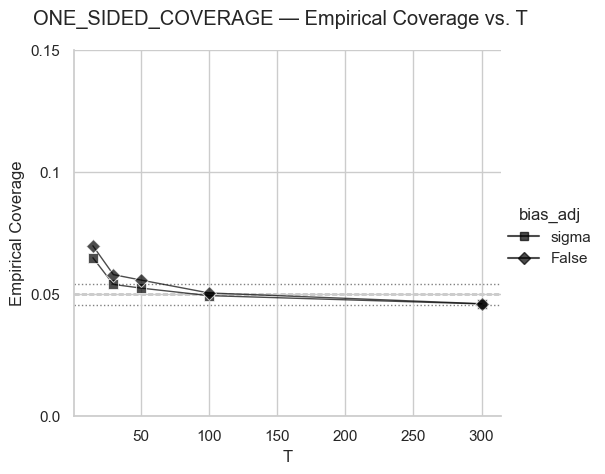

In [6]:
run_analysis(experiments, "table1_a", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs| {'yticks': [0.00, 0.05, 0.10, 0.15]})

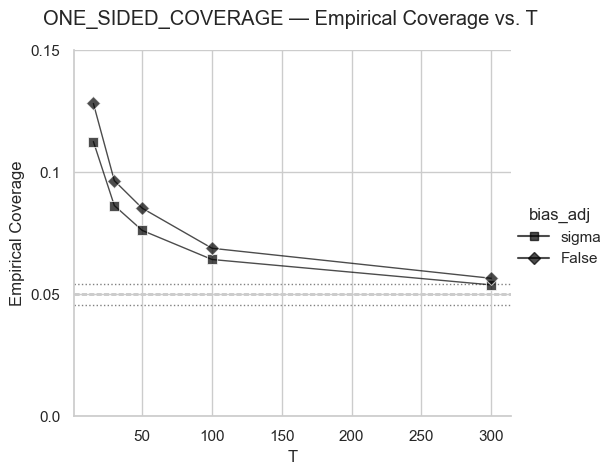

In [7]:
run_analysis(experiments, "table1_b", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs| {'yticks': [0.00, 0.05, 0.10, 0.15]})

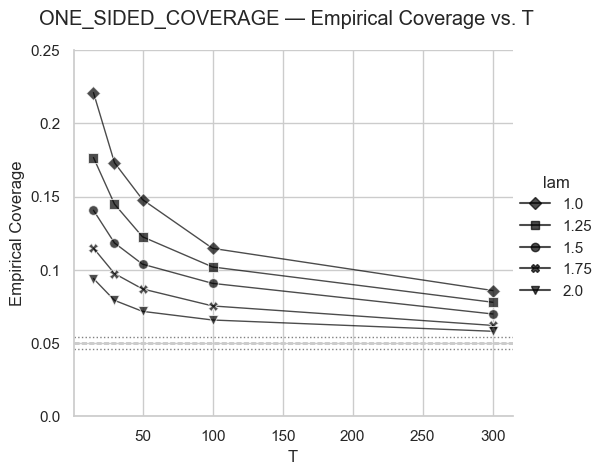

In [8]:
run_analysis(experiments, "fig5_a", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]})

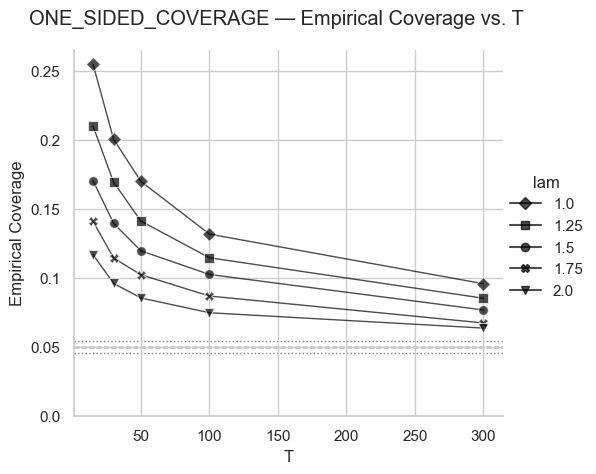

In [9]:
run_analysis(experiments, "fig5_b", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]})

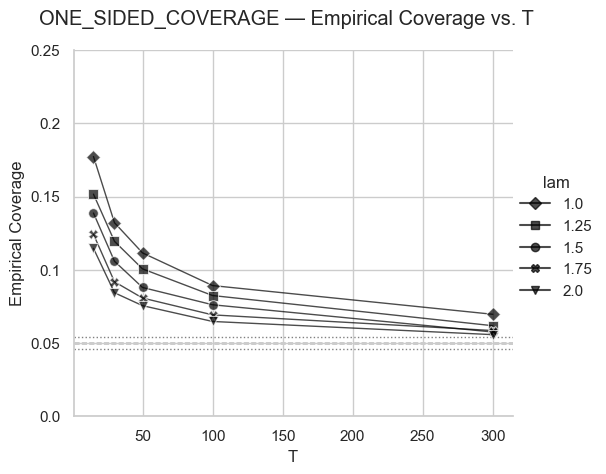

In [10]:
run_analysis(experiments, "fig5_c", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]})

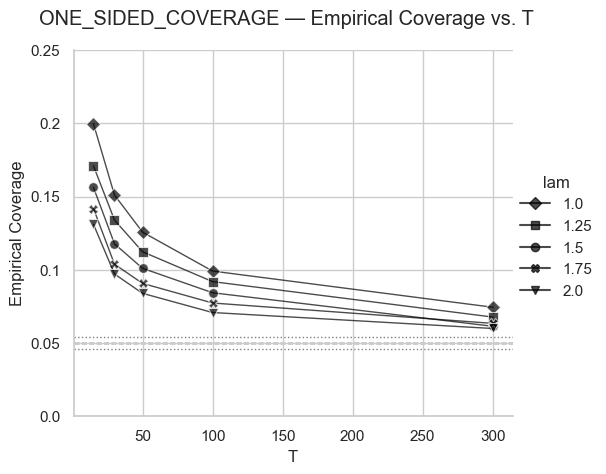

In [11]:
run_analysis(experiments, "fig5_d", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]})

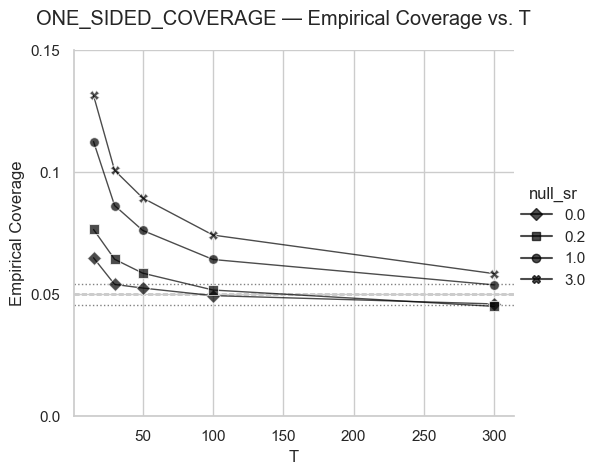

In [12]:
run_analysis(experiments, "fig6_a", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.0, 0.05, 0.10, 0.15]})

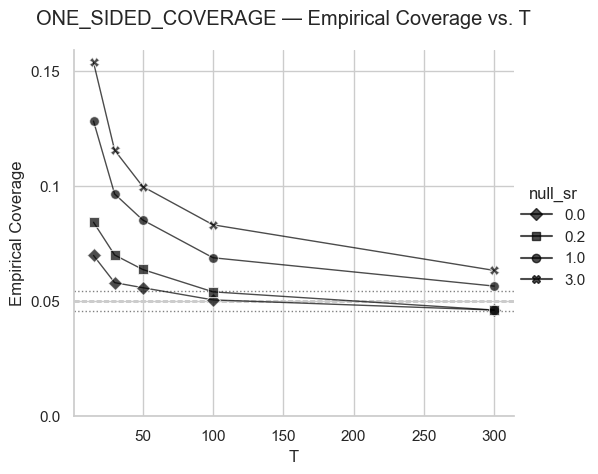

In [13]:
run_analysis(experiments, "fig6_b", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.0, 0.05, 0.10, 0.15]})

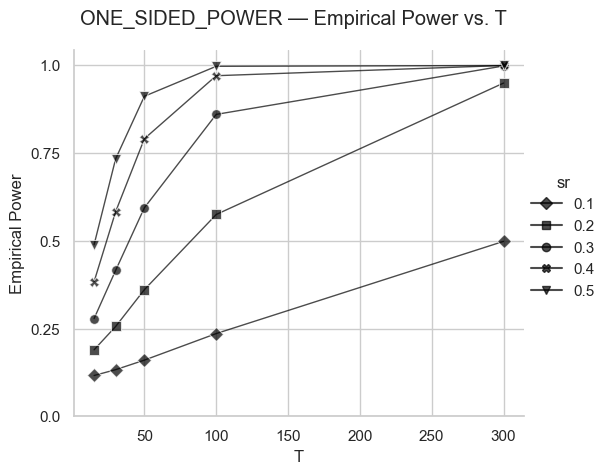

In [14]:
run_analysis(experiments, "fig7", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.0, 0.25, 0.5, 0.75, 1.0]})

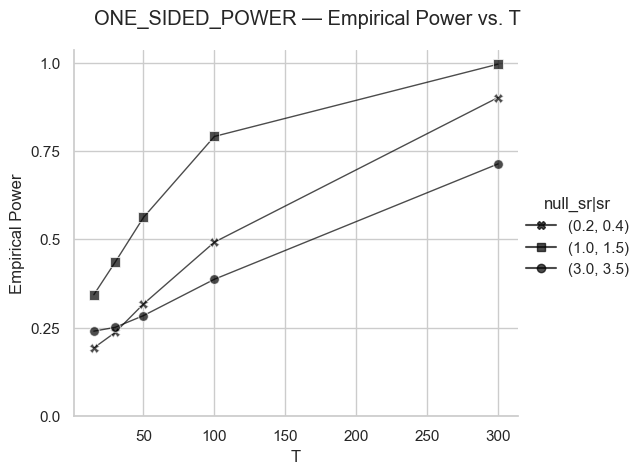

In [15]:
run_analysis(experiments, "fig8_a", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | dict(yticks= [0.0, 0.25, 0.5, 0.75, 1.0]) |
               dict(markers = ['X', 's', 'o']))

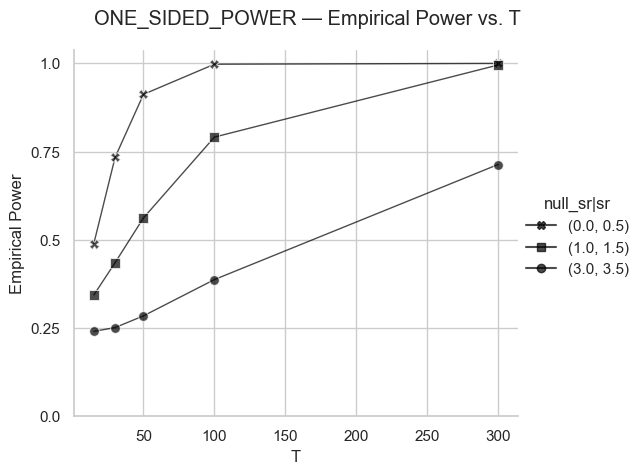

In [16]:
run_analysis(experiments, "fig8_b", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | dict(yticks= [0.0, 0.25, 0.5, 0.75, 1.0]) |
               dict(markers = ['X', 's', 'o']))